In [2]:
import tensorflow as tf

In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
X_train.shape

(55000, 28, 28)

In [5]:
X_train.dtype

dtype('uint8')

In [6]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [14]:
import matplotlib.pyplot as plt



In [7]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [8]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
class_names[y_train[0]]

'Ankle boot'

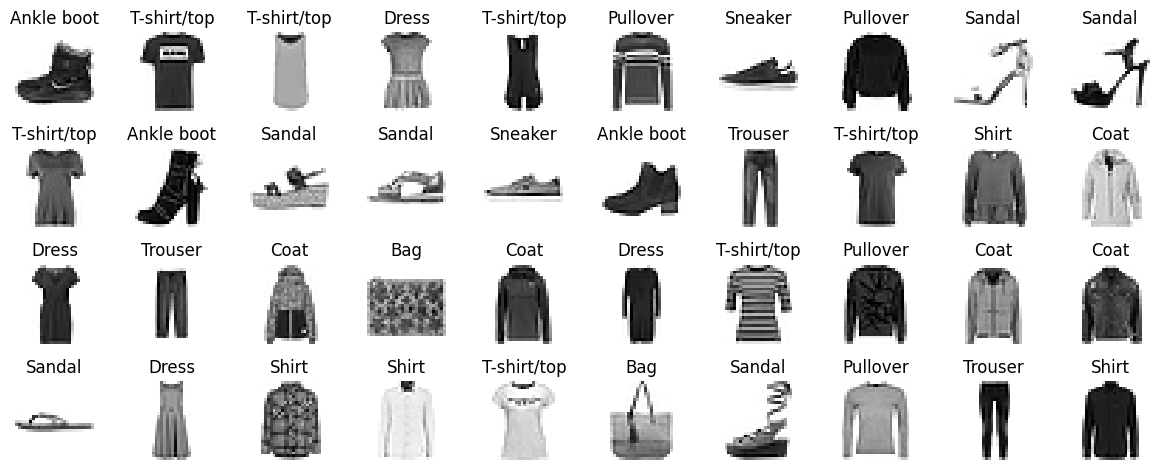

In [15]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:       # Adjust the subplot parameters to minimize unnecessary whitespace.
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# This code displays a grid of Fashion-MNIST training images with their corresponding class labels.

# Number of rows and columns for the image grid
n_rows = 4
n_cols = 10

# Create a figure with appropriate size
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

# Loop through rows and columns to display images
for row in range(n_rows):
    for col in range(n_cols):
        # Compute index of the image in the dataset
        index = n_cols * row + col

        # Create subplot position
        plt.subplot(n_rows, n_cols, index + 1)

        # Display the image
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")

        # Remove axis for cleaner visualization
        plt.axis('off')

        # Set the title as the class label
        plt.title(class_names[y_train[index]])

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Save the figure
save_fig("fashion_mnist_plot")

# Show the plot
plt.show()

In [17]:
# Building a Model with the Sequential API

tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))

# Num of neurons=10: Integer labeling also needs num_classes neurons and softmax like one-hot encoding
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [24]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9710 - loss: 0.0924 - val_accuracy: 0.8842 - val_loss: 0.4169
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9720 - loss: 0.0905 - val_accuracy: 0.8826 - val_loss: 0.4164
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9725 - loss: 0.0885 - val_accuracy: 0.8856 - val_loss: 0.4196
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9732 - loss: 0.0869 - val_accuracy: 0.8846 - val_loss: 0.4247
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9741 - loss: 0.0850 - val_accuracy: 0.8852 - val_loss: 0.4322
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9749 - loss: 0.0831 - val_accuracy: 0.8840 - val_loss: 0.4307
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9756 - loss: 0.0814 - val_accuracy: 0.8854 - val_loss: 0.4284
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9765 - loss: 0.0794 - 

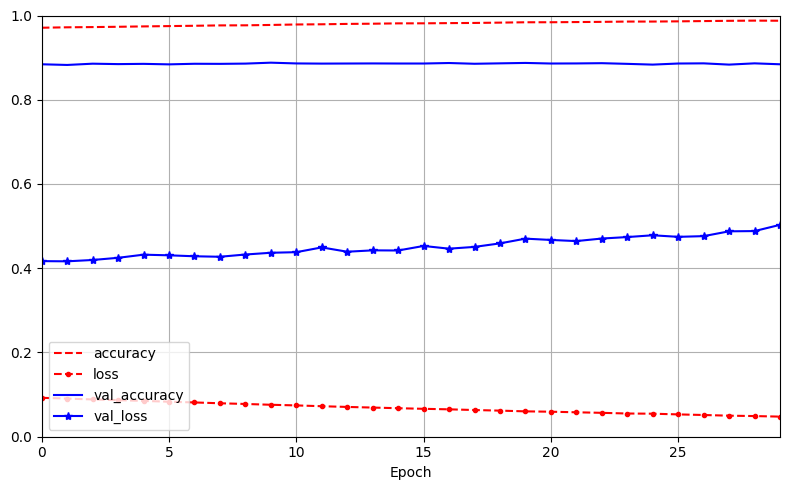

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")
save_fig("keras_learning_curves_plot")
plt.show()

In [26]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)
print(y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[7.96179164e-11 9.42051884e-14 4.06940454e-10 1.56743525e-07
  1.87332885e-10 5.06212935e-04 4.85596487e-08 1.77839698e-04
  1.17926888e-07 9.99315739e-01]
 [7.97517657e-07 1.09305814e-13 9.99985218e-01 2.10038714e-18
  1.39551858e-05 4.07589070e-18 1.58181058e-13 3.09409573e-12
  3.00783120e-16 1.14521121e-17]
 [6.79069245e-10 1.00000000e+00 9.20203571e-16 5.68215787e-12
  8.08731554e-13 3.28058321e-18 2.90866647e-17 4.62172482e-14
  9.75777974e-15 3.27424097e-20]]


In [27]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)